**Chapter 1 of Python for Finance**

Python is open sourced, aloowing flexability and open licenses 

The Cpython implementation is an interpreter of the language that translates Python code at runtime to executable byte code

Python has garabage collection, avoiding the need for the programmer to manage memory 

For over the past decade a trend has developed where the average time scale for a fianncial transaction has systematically has gone down. 

Data processing

It does not suffice to consider and process end-of-day quotes for stocks or other financial instruments; “too much” happens during the day, and for some instruments during 24 hours for 7 days a week.

Analytics speed

Decisions often have to be made in milliseconds or even faster, making it necessary to build the respective analytics capabilities and to analyze large amounts of data in real time.

Theoretical foundations

Although traditional finance theories and concepts are far from being perfect, they have been well tested (and sometimes well rejected) over time; for the millisecond and microsecond scales important as of today, consistent financial concepts and theories in the traditional sense that have proven to be somewhat robust over time are still missing.


BSM (Black-Scholes-Merton) Model, this is Equation 1-1. Black-Scholes-Merton (1973) index level at maturity:

Assume the following numerical parameter values for the valuation:

• Initial stock index level S0= 100

• Strike price of the European call option K = 105

• Time to maturity T = 1 year

• Constant, riskless short rate r = 0.05

• Constant volatility σ = 0.2

$$S_T = S_0 \exp\left(\left(r - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\, z\right) \tag{Equation 1-1}$$

The following is an algorithmic description of the Monte Carlo valuation procedure:

1. Draw I pseudo-random numbers $z(i),i \in {1,2,....,I}$, from the standard normal distribution. 

2. Calculate all resulting index levels at maturity $S_T(i)$ for given $z(i)$ and Equation 1-1

3. Calculate all inner values of the option at maturity as $h_T(i) = max(S_T(i) - K,0)$.

4. Estimate the option present value via the Monte Carlo estimator as given in Equation 1-2.

Equation 1-2. Monte Carlo estimator for European Option:
$$C_o \approx e^{rT}(1/I)\sum_i h_T(i) \tag{Equation 1-2}$$

This problem and algorithm must now be translated into Python. THe follwoing code implements the required steps:

In [11]:
import math 
import numpy as np #1

S0 = 100 #2
K = 105 #2
T = 1 #2
r = 0.05 #2
sigma = 0.2 #2

I = 100000 #2

np.random.seed(1000) #3

z = np.random.standard_normal(I) #4

ST = S0 * np.exp((r - sigma ** 2 / 2) * T + sigma * math.sqrt(T) * z) #5

hT = np.maximum(ST - K, 0) #6

C0 = math.exp(-r * T) * np.mean(hT) #7

print('Value of the European call option: {:5.3f}.'.format(C0)) #8

Value of the European call option: 8.019.


1. NumPy is used here as the main package. 

2. The model and simulation parameter values are defined. 

3. The seed value for the random number generator is fixed.

4. Standard normally distributed random numbers are drawn. 

5. End-of-period values are simulated. 

6. The option payoffs at maturity are calculated. 

7. The Monte Carlo esitmator is evaluated. 

8. The resulting value estimate is printed. 

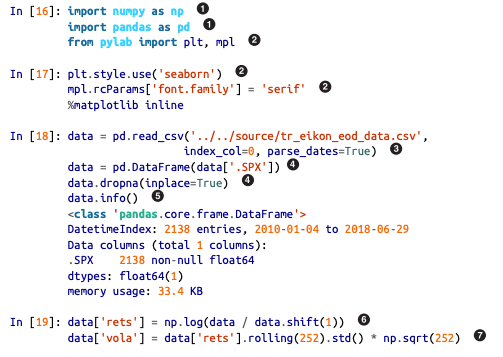
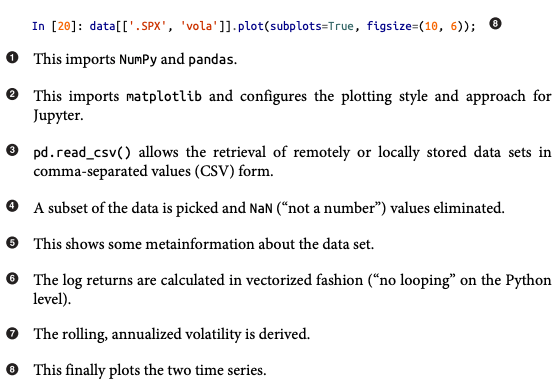

page 41
